# Example notebook for transfer learning

In [ ]:
import os
import sys
from pathlib import Path
import time
import datetime
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter
from torchvision.models.resnet import ResNet34_Weights, ResNet50_Weights
import torch.nn as nn

# Add parent directory to path so we can import src modules
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from src.training import LHmode_classifier as lh
from src.utils.utils import gen_run_name, get_project_root
from src.utils import confinement_mode_classifier as cmc

root_path = get_project_root()

# Training setup

In [ ]:
TEST_RUN = False
NUM_EPOCHS = 1
BATCH_SIZE = 32
NUM_CLASSES = 3
RIS_OPTION = 'both'
NUM_WORKERS = 8
LEARNING_RATE_MIN = 1e-5
LEARNING_RATE_MAX = 1e-4
WEIGHT_DECAY = 1e-4

run_name = gen_run_name()

In [ ]:
# Setup
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    
# Load data
shots_testing, shots_validation, shots_training = lh.load_shot_data(ris_option=RIS_OPTION, 
                                                                    test_df_contains_val_df=True, 
                                                                    test_run=TEST_RUN, #!!! Significantly reduces amount of data involved
                                                                    data_frac=1.0, 
                                                                    random_seed=42)

# Create dataloaders
dataloaders, dataset_sizes, test_dataloader = lh.create_dataloaders(shots_training, shots_testing, shots_validation,
                                                                    RIS_OPTION, 
                                                                    num_classes=NUM_CLASSES, 
                                                                    exponential_elm_decay=False,
                                                                    batch_size=BATCH_SIZE, 
                                                                    num_workers=NUM_WORKERS, 
                                                                    augmentation=False, 
                                                                    grayscale=False)


/compass/Shared/Users/bogdanov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/compass/Shared/Users/bogdanov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/compass/Shared/Users/bogdanov/.venv/l

In [21]:
display(dataset_sizes)

{'train': 7874, 'val': 12482}

# Last FC layer training

In [4]:
# Setup model
pretrained_model = torchvision.models.resnet18()

# Freeze all parameters initially
for param in pretrained_model.parameters():
    param.requires_grad = False
    
# Replace the final fully connected layer
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(num_ftrs, 3)
pretrained_model = pretrained_model.to(device)

In [22]:
# Train only FC layer
run_dir_fc = root_path / 'runs' / f'{run_name}_last_fc'
writer = SummaryWriter(str(run_dir_fc))

# Set parameter gradients based on training phase
for param in pretrained_model.parameters():
    param.requires_grad = False

# Always allow gradients for the final layer
for param in pretrained_model.fc.parameters():
    param.requires_grad = True

# Setup training components
criterion = nn.CrossEntropyLoss()
optimizer, exp_lr_scheduler = lh.create_optimizer_and_scheduler(pretrained_model, LEARNING_RATE_MIN, 
                                                             LEARNING_RATE_MAX, WEIGHT_DECAY,
                                                             dataset_sizes['train'], NUM_EPOCHS)

print(f'Model will be saved to {run_dir_fc}')

Model will be saved to /compass/Shared/Users/bogdanov/ml_tokamak/runs/quick_tree_last_fc


## Train the frozen model

In [ ]:
# Model save paths
model_path_fc = run_dir_fc / 'model.pt'
chkpt_path_fc = run_dir_fc / f'model_best_val_acc.pt'

fc_model = cmc.train_model(pretrained_model, criterion, 
                           optimizer, exp_lr_scheduler, 
                           dataloaders, writer, dataset_sizes, 
                           num_epochs=NUM_EPOCHS,
                           chkpt_path=chkpt_path_fc,
                           return_best_model=False # return model without early stopping. Both are saved anyways
                           ) 

# Save model
torch.save(fc_model.state_dict(), model_path_fc)
writer.close()

INFO:src.utils.confinement_mode_classifier:Epoch 1/1
INFO:src.utils.confinement_mode_classifier:----------
100%|██████████| 247/247 [01:53<00:00,  2.17it/s]
INFO:src.utils.confinement_mode_classifier:train Loss: 1.1009 Acc: 0.3363
100%|██████████| 391/391 [01:31<00:00,  4.29it/s]
INFO:src.utils.confinement_mode_classifier:val Loss: 1.1002 Acc: 0.3306
INFO:src.utils.confinement_mode_classifier:Training complete in 3m 25s
INFO:src.utils.confinement_mode_classifier:Best val Acc: 0.330556


## Test the frozen model

Processing batches:   0%|          | 0/391 [00:00<?, ?it/s]/compass/Shared/Users/bogdanov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Processing batches: 100%|██████████| 391/391 [01:27<00:00,  4.47it/s]
INFO:src.utils.confinement_mode_classifier:Processing metrics...
/compass/Shared/Users/bogdanov/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} 

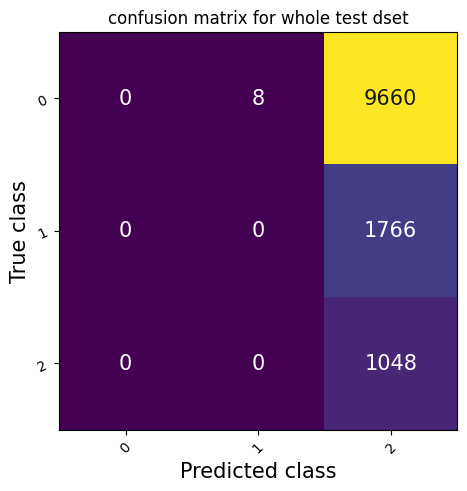

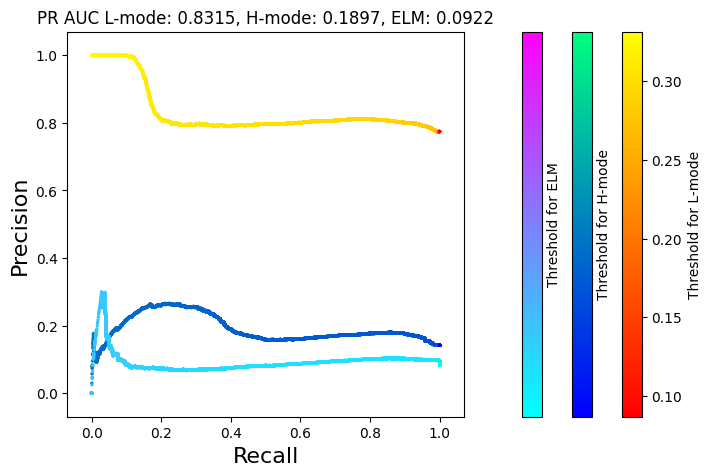

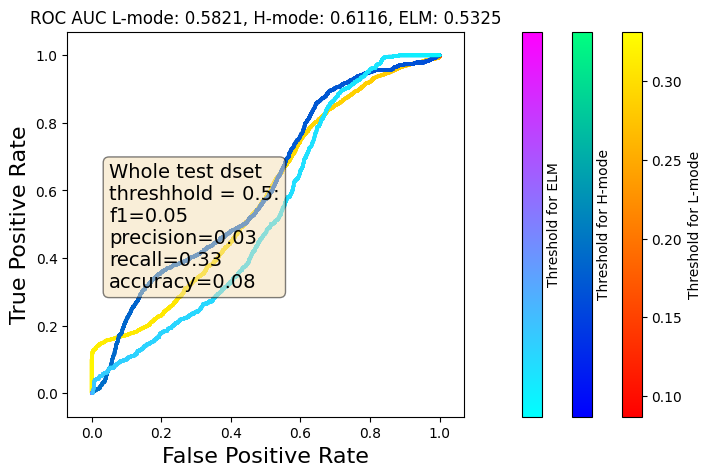

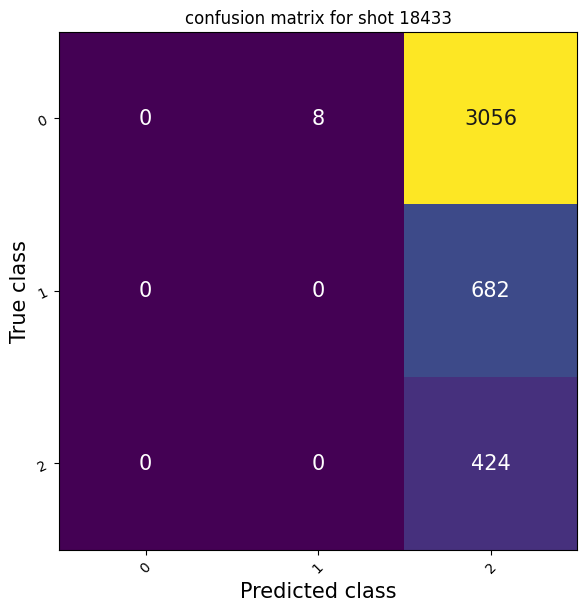

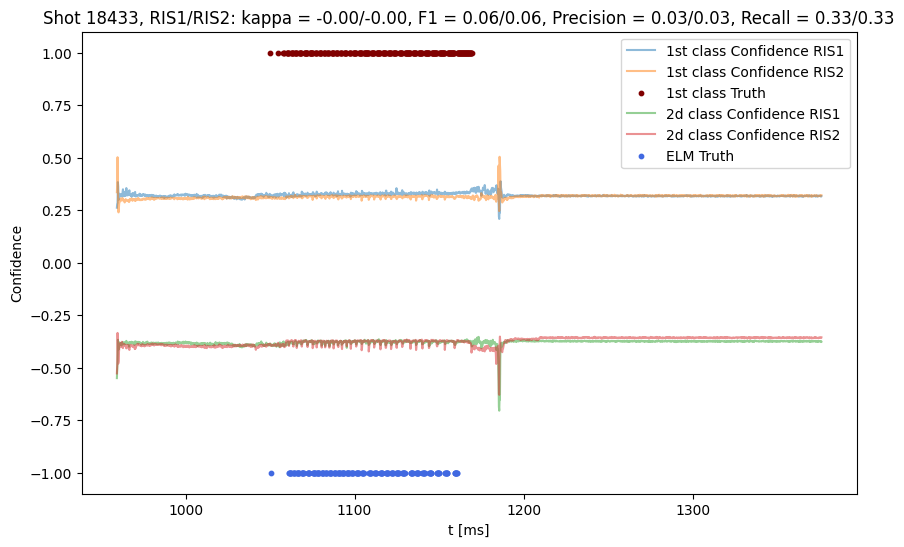

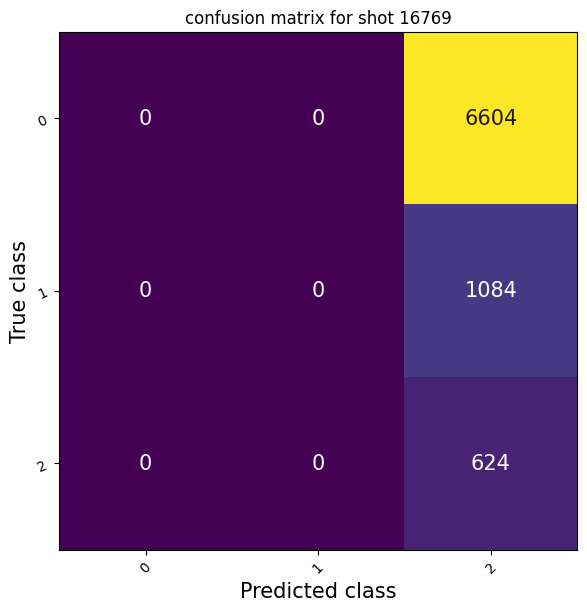

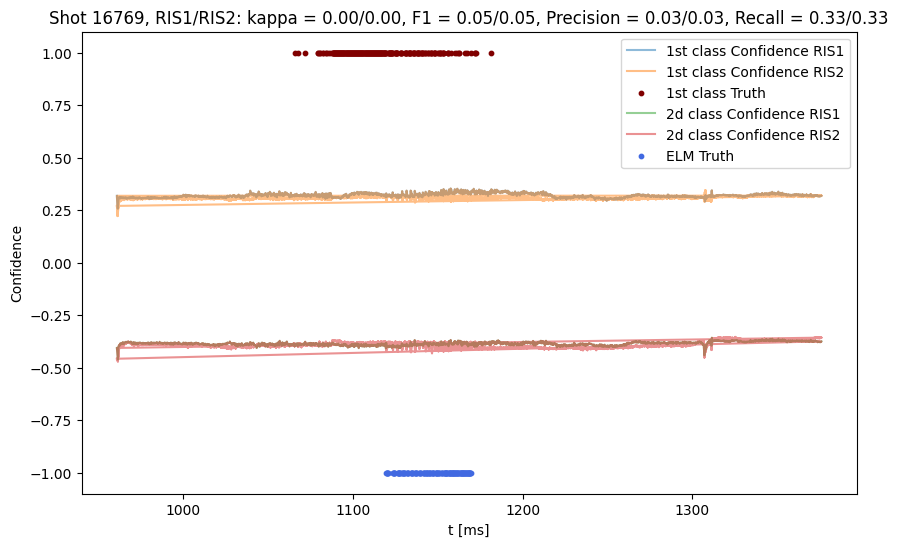

In [13]:
fc_test_dict = cmc.test_model(run_dir_fc, 
                              fc_model, 
                              test_dataloader, 
                              return_metrics=True, 
                              writer=writer,
                              signal_name='img')

fc_test_dict_per_shot = cmc.per_shot_test(run_dir_fc,
                                          shots_testing,
                                          fc_test_dict['prediction_df'],
                                          writer,
                                          save_metrics_imgs=True,
                                          two_images=RIS_OPTION=='both')

In [17]:
display(fc_test_dict.keys())
display(fc_test_dict_per_shot)

dict_keys(['prediction_df', 'confusion_matrix', 'f1', 'precision', 'recall', 'accuracy', 'pr_roc_curves'])

{'shot': [18433, 16769],
 'f1': [0.061636877546352296, 0.046553267681289166],
 'precision': [0.033958040838444295, 0.02502406159769009],
 'recall': [0.3333333333333333, 0.3333333333333333],
 'kappa': [-0.00013214990037924146, 0.0]}

# Train all layers

In [18]:
# Train all layers
run_dir_all = root_path / 'runs' / f'{run_name}_all_layers'
writer = SummaryWriter(str(run_dir_all))

# Unfreeze all layers
for param in fc_model.parameters():
    param.requires_grad = True


criterion = nn.CrossEntropyLoss()
optimizer, exp_lr_scheduler = lh.create_optimizer_and_scheduler(fc_model, LEARNING_RATE_MIN, 
                                                             LEARNING_RATE_MAX, WEIGHT_DECAY,
                                                             dataset_sizes['train'], NUM_EPOCHS)

# Model save paths
model_path_all = run_dir_all / 'model.pt'
chkpt_path_all = run_dir_all / f'model_best_val_acc.pt'

all_layers_model = cmc.train_model(fc_model, criterion, 
                                    optimizer, exp_lr_scheduler, 
                                    dataloaders, writer, dataset_sizes, 
                                    num_epochs=NUM_EPOCHS,
                                    chkpt_path=chkpt_path_all,
                                    return_best_model=False
                                    ) 

# Save model
torch.save(all_layers_model.state_dict(), model_path_all)
writer.close()

INFO:src.utils.confinement_mode_classifier:Epoch 1/1
INFO:src.utils.confinement_mode_classifier:----------
  0%|          | 0/247 [00:00<?, ?it/s]/compass/Shared/Users/bogdanov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 247/247 [01:00<00:00,  4.05it/s]
INFO:src.utils.confinement_mode_classifier:train Loss: 0.6906 Acc: 0.7283
100%|██████████| 391/391 [01:29<00:00,  4.35it/s]
INFO:src.utils.confinement_mode_classifier:val Loss: 1.2062 Acc: 0.5289
INFO:src.utils.confinement_mode_classifier:Training complete in 2m 31s
INFO:src.utils.confinement_mode_classifier:Best val Acc:

In [20]:
all_test_dict = cmc.test_model(run_dir_all, 
                              all_layers_model, 
                              test_dataloader, 
                              return_metrics=True, 
                              writer=writer,
                              signal_name='img')

all_test_dict_per_shot = cmc.per_shot_test(run_dir_all,
                                          shots_testing,
                                          all_test_dict['prediction_df'],
                                          writer,
                                          save_metrics_imgs=True,
                                          two_images=RIS_OPTION=='both')

Processing batches:   0%|          | 0/391 [00:00<?, ?it/s]/compass/Shared/Users/bogdanov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Processing batches: 100%|██████████| 391/391 [01:26<00:00,  4.50it/s]
INFO:src.utils.confinement_mode_classifier:Processing metrics...
  0%|          | 0/2 [00:00<?, ?it/s]/compass/Shared/Users/bogdanov/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## Investigate CE Loss for `fc` vs `all`
Find confidences for wrong predictions made for test dset

If the training is complete replace `read_csv` with `all_test_dict['prediction_df']` and `fc_test_dict['prediction_df']` 


In [51]:
import pandas as pd

#df_all = all_test_dict['prediction_df']
#df_fc = fc_test_dict['prediction_df']

df_all = pd.read_csv('../runs/24-05-27, 20-00-44 both, finer lr_scheduler, 3 classes, resnet34_all_layers/prediction_df.csv', index_col=0)
df_fc = pd.read_csv('../runs/24-05-27, 20-00-44 both, finer lr_scheduler, 3 classes, resnet34_last_fc/prediction_df.csv', index_col=0)

confidences_wrong_preds_all = df_all[df_all['prediction']!=df_all['label']].apply(lambda x: x[f'prob_{int(x["prediction"])}'], axis=1)


confidences_wrong_preds_fc = df_fc[df_fc['prediction']!=df_fc['label']].apply(lambda x: x[f'prob_{int(x["prediction"])}'], axis=1)

In [52]:
display(confidences_wrong_preds_fc.mean())
display(confidences_wrong_preds_all.mean())

np.float64(0.5951993688117857)

np.float64(0.8754690789640479)

In [56]:
def calc_cel(preds, targets):
    closs = nn.CrossEntropyLoss()
    calculate_loss = closs(preds, targets)
    return calculate_loss

targets_all = torch.tensor(df_all['label'].values)
preds_all = torch.tensor(df_all[[f'prob_{i}' for i in range(3)]].to_numpy())

cel_all = calc_cel(preds_all, targets_all)

targets_fc = torch.tensor(df_fc['label'].values)
preds_fc = torch.tensor(df_fc[[f'prob_{i}' for i in range(3)]].to_numpy())

cel_fc = calc_cel(preds_fc, targets_fc)

print(f'CEL all layers: {cel_all.item():.3f} \nCEL last FC {cel_fc.item():.3f}')

CEL all layers: 0.586 
CEL last FC 0.696


# Training loss curves

I log it to tensorboard only...

In [ ]:
%load_ext tensorboard

%tensorboard --logdir=../runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 3701632), started 0:00:24 ago. (Use '!kill 3701632' to kill it.)